<a href="https://colab.research.google.com/github/flaviocrispin/tecnica_programacao/blob/colaborador%2Fsilas-valerio/Aula_pandas_ada4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [91]:
df = pd.read_csv('/content/drive/MyDrive/DimCustomer.csv',  parse_dates=["BirthDate"], date_format="%Y-%m-%d")

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18869 entries, 0 to 18868
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Unnamed: 0            18869 non-null  int64         
 1   CustomerKey           18869 non-null  int64         
 2   GeographyKey          18869 non-null  int64         
 3   FirstName             18869 non-null  object        
 4   LastName              18869 non-null  object        
 5   BirthDate             18869 non-null  datetime64[ns]
 6   MaritalStatus         18869 non-null  object        
 7   Gender                18869 non-null  object        
 8   YearlyIncome          18869 non-null  float64       
 9   TotalChildren         18869 non-null  float64       
 10  NumberChildrenAtHome  18869 non-null  float64       
 11  Education             18869 non-null  object        
 12  Occupation            18869 non-null  object        
 13  HouseOwnerFlag  

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18869 entries, 0 to 18868
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            18869 non-null  int64  
 1   CustomerKey           18869 non-null  int64  
 2   GeographyKey          18869 non-null  int64  
 3   FirstName             18869 non-null  object 
 4   LastName              18869 non-null  object 
 5   BirthDate             18869 non-null  object 
 6   MaritalStatus         18869 non-null  object 
 7   Gender                18869 non-null  object 
 8   YearlyIncome          18869 non-null  float64
 9   TotalChildren         18869 non-null  float64
 10  NumberChildrenAtHome  18869 non-null  float64
 11  Education             18869 non-null  object 
 12  Occupation            18869 non-null  object 
 13  HouseOwnerFlag        18869 non-null  float64
 14  NumberCarsOwned       18869 non-null  float64
dtypes: float64(5), int6

In [17]:
df['Occupation'].describe()

,Occupation
count,18869
unique,5
top,Professional
freq,5606


In [18]:
df.columns

Index(['Unnamed: 0', 'CustomerKey', 'GeographyKey', 'FirstName', 'LastName',
       'BirthDate', 'MaritalStatus', 'Gender', 'YearlyIncome', 'TotalChildren',
       'NumberChildrenAtHome', 'Education', 'Occupation', 'HouseOwnerFlag',
       'NumberCarsOwned'],
      dtype='object')

In [22]:
df.select_dtypes(include='number').describe().round(2)

,Unnamed: 0,CustomerKey,GeographyKey,YearlyIncome,TotalChildren,NumberChildrenAtHome,HouseOwnerFlag,NumberCarsOwned
count,18869.00,18869.00,18869.00,18869.00,18869.00,18869.00,18869.00,18869.00
mean,9434.00,9440.63,574.91,260174.89,1.86,1.03,0.67,1.51
std,5447.16,5456.84,84.16,1406070.94,1.62,1.54,0.47,1.15
min,0.00,1.00,423.00,10000.00,0.00,0.00,0.00,0.00
25%,4717.00,4718.00,506.00,30000.00,0.00,0.00,0.00,1.00
50%,9434.00,9435.00,568.00,60000.00,2.00,0.00,1.00,2.00
75%,14151.00,14152.00,645.00,80000.00,3.00,2.00,1.00,2.00
max,18868.00,19145.00,952.00,10000000.00,5.00,5.00,1.00,4.00


In [96]:
for i in df.select_dtypes(include='int64'):
  print(i)

Unnamed: 0
CustomerKey
GeographyKey


In [26]:
df['BirthDate'].head(5)

,BirthDate
0,1966-04-08
1,1965-05-14
2,1965-08-12
3,1968-02-15
4,1968-08-08


In [28]:
df['data_nascimento']=pd.to_datetime(df['BirthDate'])

In [29]:
df['data_nascimento'].head(5)

,data_nascimento
0,1966-04-08
1,1965-05-14
2,1965-08-12
3,1968-02-15
4,1968-08-08


In [40]:
if ['data_nascimento'] in list(df.columns):
  print('si')
  df.drop(columns=["data_nascimentoBR"], inplace=True)

In [41]:
df.columns

Index(['Unnamed: 0', 'CustomerKey', 'GeographyKey', 'FirstName', 'LastName',
       'BirthDate', 'MaritalStatus', 'Gender', 'YearlyIncome', 'TotalChildren',
       'NumberChildrenAtHome', 'Education', 'Occupation', 'HouseOwnerFlag',
       'NumberCarsOwned', 'data_nascimento'],
      dtype='object')

In [42]:
df.head(5)

,Unnamed: 0,CustomerKey,GeographyKey,FirstName,LastName,BirthDate,MaritalStatus,Gender,YearlyIncome,TotalChildren,NumberChildrenAtHome,Education,Occupation,HouseOwnerFlag,NumberCarsOwned,data_nascimento
0,0,1,680,Jon,Yang,1966-04-08,M,M,90000.0,2.0,0.0,Bachelors,Professional,1.0,0.0,1966-04-08
1,1,2,692,Eugene,Huang,1965-05-14,S,M,60000.0,3.0,3.0,Bachelors,Professional,0.0,1.0,1965-05-14
2,2,3,493,Ruben,Torres,1965-08-12,M,M,60000.0,3.0,3.0,Bachelors,Professional,1.0,1.0,1965-08-12
3,3,4,519,Christy,Zhu,1968-02-15,S,F,70000.0,0.0,0.0,Bachelors,Professional,0.0,1.0,1968-02-15
4,4,5,706,Elizabeth,Johnson,1968-08-08,S,F,80000.0,5.0,5.0,Bachelors,Professional,1.0,4.0,1968-08-08


In [43]:
df['estado_civil']=df['MaritalStatus'].apply(lambda x: 'casado' if x == "M" else 'solteiro')

In [44]:
df.head(5)

,Unnamed: 0,CustomerKey,GeographyKey,FirstName,LastName,BirthDate,MaritalStatus,Gender,YearlyIncome,TotalChildren,NumberChildrenAtHome,Education,Occupation,HouseOwnerFlag,NumberCarsOwned,data_nascimento,estado_civil
0,0,1,680,Jon,Yang,1966-04-08,M,M,90000.0,2.0,0.0,Bachelors,Professional,1.0,0.0,1966-04-08,casado
1,1,2,692,Eugene,Huang,1965-05-14,S,M,60000.0,3.0,3.0,Bachelors,Professional,0.0,1.0,1965-05-14,solteiro
2,2,3,493,Ruben,Torres,1965-08-12,M,M,60000.0,3.0,3.0,Bachelors,Professional,1.0,1.0,1965-08-12,casado
3,3,4,519,Christy,Zhu,1968-02-15,S,F,70000.0,0.0,0.0,Bachelors,Professional,0.0,1.0,1968-02-15,solteiro
4,4,5,706,Elizabeth,Johnson,1968-08-08,S,F,80000.0,5.0,5.0,Bachelors,Professional,1.0,4.0,1968-08-08,solteiro


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18869 entries, 0 to 18868
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Unnamed: 0            18869 non-null  int64         
 1   CustomerKey           18869 non-null  int64         
 2   GeographyKey          18869 non-null  int64         
 3   FirstName             18869 non-null  object        
 4   LastName              18869 non-null  object        
 5   BirthDate             18869 non-null  object        
 6   MaritalStatus         18869 non-null  object        
 7   Gender                18869 non-null  object        
 8   YearlyIncome          18869 non-null  float64       
 9   TotalChildren         18869 non-null  float64       
 10  NumberChildrenAtHome  18869 non-null  float64       
 11  Education             18869 non-null  object        
 12  Occupation            18869 non-null  object        
 13  HouseOwnerFlag  

Text(0, 0.5, 'Frequência')

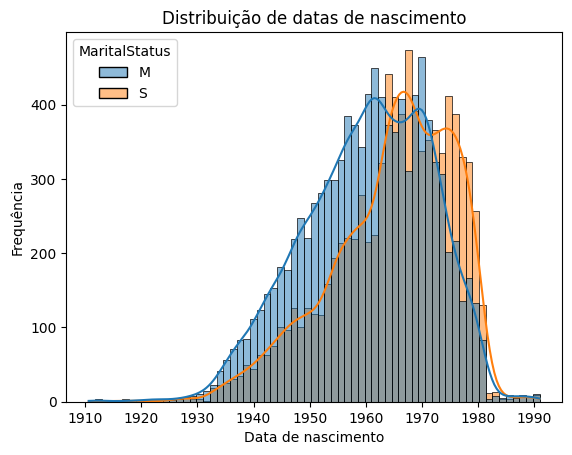

In [67]:
sns.histplot(data=df,x='data_nascimento',kde='true', hue='MaritalStatus')
plt.title('Distribuição de datas de nascimento')
plt.xlabel('Data de nascimento')
plt.ylabel('Frequência')

Text(0, 0.5, 'Quantidade de clientes')

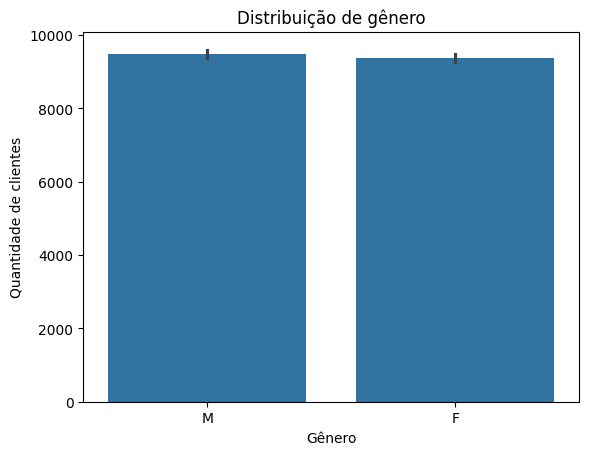

In [73]:
sns.barplot(data=df,x='Gender',y='CustomerKey', legend='auto')
plt.title('Distribuição de gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de clientes')


Text(0, 0.5, 'Quantidade de clientes')

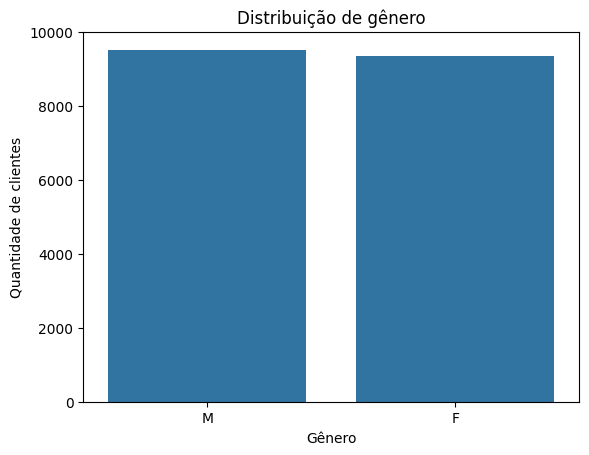

In [75]:
sns.countplot(data=df,x='Gender')
plt.title('Distribuição de gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de clientes')


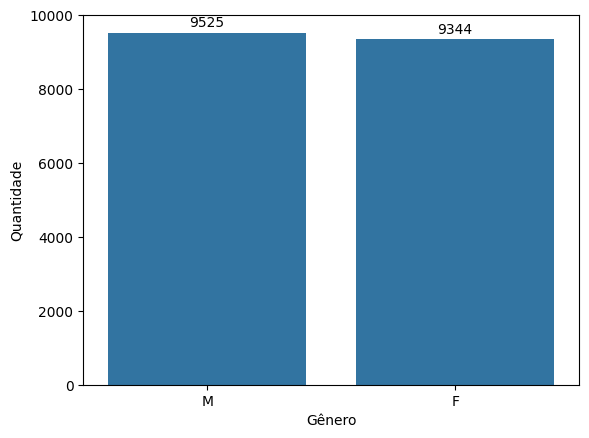

In [79]:
ax = sns.countplot(data=df, x="Gender")

ax.bar_label(
    ax.containers[0],
    padding=2
)

ax.set_xlabel("Gênero")
ax.set_ylabel("Quantidade")
plt.show()